# Part 1

In [2]:
import numpy as np
import cv2 as cv

In [3]:
sift = cv.SIFT_create()

print("SIFT Detector Parameters:")
print("contrastThreshold:", sift.getContrastThreshold())
print("edgeThreshold:", sift.getEdgeThreshold())
print("sigma:", sift.getSigma())

print("\nParameter Ranges:")
print("contrastThreshold: 0.03-0.09 (default: 0.04)")
print("edgeThreshold: 5-20 (default: 10)")
print("sigma: 1.6 (default)")
print("nfeatures: 0 (default = unlimited)")

SIFT Detector Parameters:
contrastThreshold: 0.04
edgeThreshold: 10.0
sigma: 1.6

Parameter Ranges:
contrastThreshold: 0.03-0.09 (default: 0.04)
edgeThreshold: 5-20 (default: 10)
sigma: 1.6 (default)
nfeatures: 0 (default = unlimited)


In [4]:
img_path = 'images/example-image.jpg'
img = cv.imread(img_path)

gray= cv.cvtColor(img,cv.COLOR_BGR2GRAY)

sift = cv.SIFT_create()
keypoints = sift.detect(gray, None)
 
output_img = cv.drawKeypoints(gray, keypoints, img, flags = cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
cv.imwrite('SIFT_default.jpg', output_img)
print('Saved SIFT visualization to SIFT_default.jpg')

Saved SIFT visualization to SIFT_default.jpg


In [5]:
print("Total keypoints detected:", len(keypoints))

if len(keypoints) > 0:
    kp = keypoints[0]  # Get first keypoint
    print("\nKeypoint attributes:", [attr for attr in dir(kp) if not attr.startswith('_')])
    
    print("\nFirst keypoint details:")
    print("Position (x, y):", kp.pt)
    print("Size (diameter):", kp.size)
    print("Angle (orientation):", kp.angle)
    print("Response (strength):", kp.response)
    print("Octave:", kp.octave)
    print("Class ID:", kp.class_id)


Total keypoints detected: 387

Keypoint attributes: ['angle', 'class_id', 'convert', 'octave', 'overlap', 'pt', 'response', 'size']

First keypoint details:
Position (x, y): (25.056865692138672, 96.4741439819336)
Size (diameter): 22.15937614440918
Angle (orientation): 29.3697509765625
Response (strength): 0.01890508085489273
Octave: 14615042
Class ID: -1


# Part 2

In [6]:
# Re-initialize SIFT with different thresholds, save visualizations, and print counts.
params = [(0.02, 5), (0.03, 5), (0.03, 10), (0.03, 15), (0.04, 10), (0.05, 10)]
best_count = -1
best_contrast = None
best_edge = None
best_file = None
for contrast, edge in params:
    sift_t = cv.SIFT_create(contrastThreshold = contrast, edgeThreshold = edge)
    kps = sift_t.detect(gray, None)
    out = cv.drawKeypoints(gray, kps, img.copy(), flags = cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    filename = f'sift_contrast{contrast}_edge{edge}.jpg'
    cv.imwrite(filename, out)
    print(f'Contrast = {contrast}, Edge = {edge}, and {len(kps)} Keypoints; Stored in ({filename})')
    if len(kps) > best_count:
        best_count = len(kps)
        best_contrast = contrast
        best_edge = edge
        best_file = filename
print(f'Best: Contrast = {best_contrast} Edge = {best_edge} Count = {best_count} File = {best_file}')

Contrast = 0.02, Edge = 5, and 290 Keypoints; Stored in (sift_contrast0.02_edge5.jpg)
Contrast = 0.03, Edge = 5, and 266 Keypoints; Stored in (sift_contrast0.03_edge5.jpg)
Contrast = 0.03, Edge = 10, and 441 Keypoints; Stored in (sift_contrast0.03_edge10.jpg)
Contrast = 0.03, Edge = 5, and 266 Keypoints; Stored in (sift_contrast0.03_edge5.jpg)
Contrast = 0.03, Edge = 10, and 441 Keypoints; Stored in (sift_contrast0.03_edge10.jpg)
Contrast = 0.03, Edge = 15, and 570 Keypoints; Stored in (sift_contrast0.03_edge15.jpg)
Contrast = 0.03, Edge = 15, and 570 Keypoints; Stored in (sift_contrast0.03_edge15.jpg)
Contrast = 0.04, Edge = 10, and 387 Keypoints; Stored in (sift_contrast0.04_edge10.jpg)
Contrast = 0.04, Edge = 10, and 387 Keypoints; Stored in (sift_contrast0.04_edge10.jpg)
Contrast = 0.05, Edge = 10, and 328 Keypoints; Stored in (sift_contrast0.05_edge10.jpg)
Best: Contrast = 0.03 Edge = 15 Count = 570 File = sift_contrast0.03_edge15.jpg
Contrast = 0.05, Edge = 10, and 328 Keypoints;

# Part 3

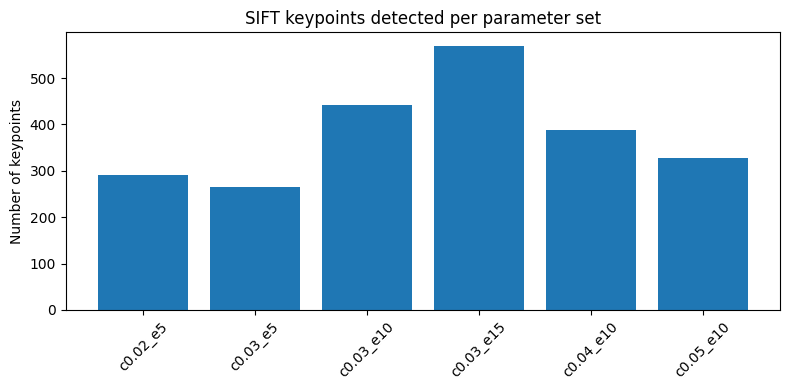

Best parameters by count -> contrast = 0.03, edge = 15, keypoints = 570


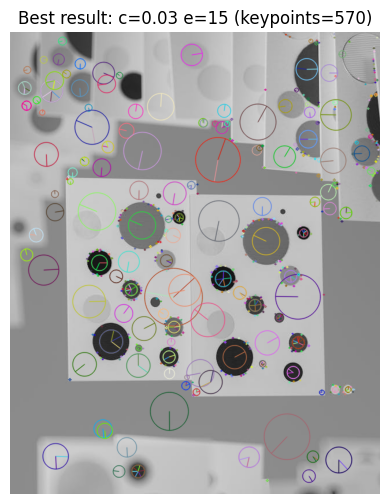

In [9]:
import matplotlib.pyplot as plt
params = [(0.02, 5), (0.03, 5), (0.03, 10), (0.03, 15), (0.04, 10), (0.05, 10)]
counts = []
results = []
for contrast, edge in params:
    sift_t = cv.SIFT_create(contrastThreshold=float(contrast), edgeThreshold=int(edge))
    kps = sift_t.detect(gray, None)
    out = cv.drawKeypoints(gray, kps, img.copy(), flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    counts.append(len(kps))
    results.append((contrast, edge, out))
# Plot counts
labels = [f'c{c}_e{e}' for c,e in params]
plt.figure(figsize=(8,4))
plt.bar(labels, counts, color='tab:blue')
plt.xticks(rotation=45)
plt.ylabel('Number of keypoints')
plt.title('SIFT keypoints detected per parameter set')
plt.tight_layout()
plt.show()
# Display best result
best_idx = int(np.argmax(counts)) if len(counts) > 0 else None
bc, be, bout = results[best_idx]
print(f'Best parameters by count -> contrast = {bc}, edge = {be}, keypoints = {counts[best_idx]}')
display_img = cv.cvtColor(bout, cv.COLOR_BGR2RGB)
plt.figure(figsize=(6,6))
plt.imshow(display_img)
plt.axis('off')
plt.title(f'Best result: c={bc} e={be} (keypoints={counts[best_idx]})')
plt.show()

# Part 4

Feature matching via SIFT: create a transformed version of the original image (rotation, scaling, affine/perspective), call it `image2`, compute descriptors for `image1` and `image2`, run a brute-force matcher, and draw the top matches. The transformed image will be saved as `images/example-image-transformed.jpg`.

Saved transformed image to images\example-image-transformed.jpg
Keypoints image1: 722 Keypoints image2: 505
Found 248 total matches; showing top 50
Saved match visualization to sift_matches.jpg


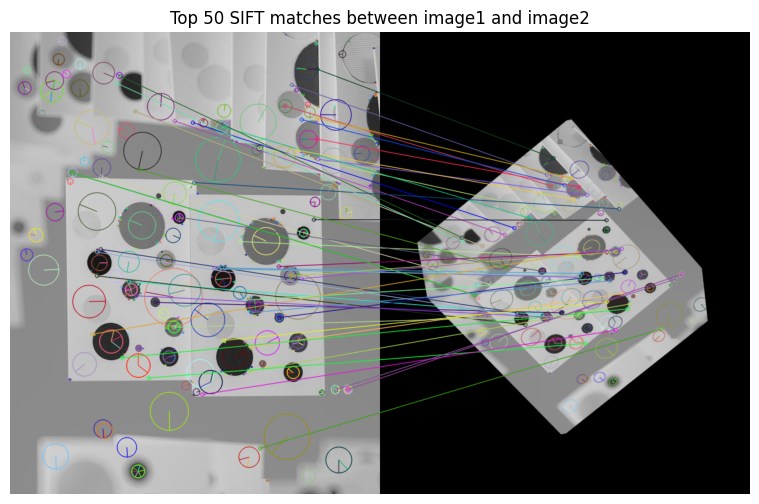

In [11]:
image1 = img.copy()
rows, cols = image1.shape[:2]

# Rotate and scale
M_rot = cv.getRotationMatrix2D((cols/2, rows/2), 30, 0.8)
img_rot = cv.warpAffine(image1, M_rot, (cols, rows))

# Affine warp
pts1 = np.float32([[0,0], [cols-1,0], [0,rows-1]])
pts2 = np.float32([[0,0.25*rows], [0.85*(cols-1), 0.05*rows], [0.15*(cols-1), rows-1]])
M_aff = cv.getAffineTransform(pts1, pts2)
img_aff = cv.warpAffine(img_rot, M_aff, (cols, rows))

# Small perspective change
pts_src = np.float32([[0,0], [cols-1,0], [cols-1,rows-1], [0,rows-1]])
pts_dst = np.float32([[0.05*cols, 0.03*rows], [cols-1-0.05*cols, 0.10*rows], [cols-1-0.10*cols, rows-1-0.05*rows], [0.08*cols, rows-1-0.08*rows]])
M_pers = cv.getPerspectiveTransform(pts_src, pts_dst)
img_pers = cv.warpPerspective(img_aff, M_pers, (cols, rows))

out_path = os.path.join('images','example-image-transformed.jpg')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
cv.imwrite(out_path, img_pers)
print(f'Saved transformed image to {out_path}')

image2 = img_pers
gray1 = cv.cvtColor(image1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(image2, cv.COLOR_BGR2GRAY)
sift = cv.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)
print('Keypoints image1:', len(keypoints), 'Keypoints image2:', len(keypoints2))

# Ensure descriptors exist
if descriptors is None or descriptors2 is None:
    print('One of the descriptor sets is empty; aborting matching.')
else:
    # Brute-force matcher with L2 and cross-checking
    bf = cv.BFMatcher(cv.NORM_L2, crossCheck=True)
    matches = bf.match(descriptors, descriptors2)
    matches = sorted(matches, key=lambda x: x.distance)
    print(f'Found {len(matches)} total matches; showing top 50')
    # Draw top matches
    draw_count = min(50, len(matches))
    matched_img = cv.drawMatches(image1, keypoints, image2, keypoints2, matches[:draw_count], None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    # Save and display
    match_out = 'sift_matches.jpg'
    cv.imwrite(match_out, matched_img)
    print(f'Saved match visualization to {match_out}')
    # Display with matplotlib (convert BGR->RGB)
    disp = cv.cvtColor(matched_img, cv.COLOR_BGR2RGB)
    plt.figure(figsize=(12,6))
    plt.imshow(disp)
    plt.axis('off')
    plt.title(f'Top {draw_count} SIFT matches between image1 and image2')
    plt.show()